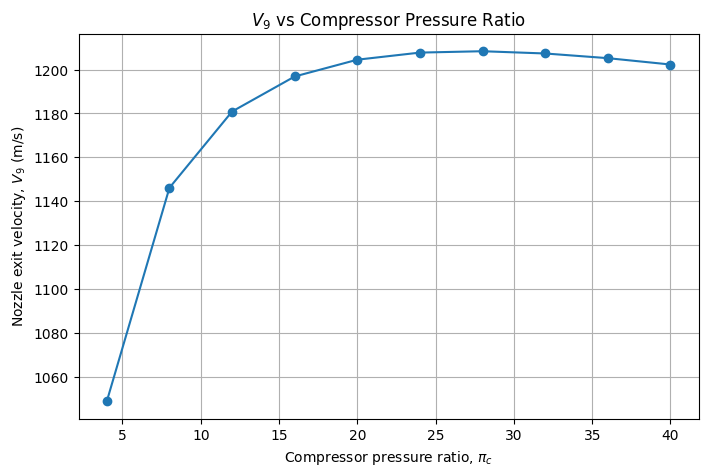

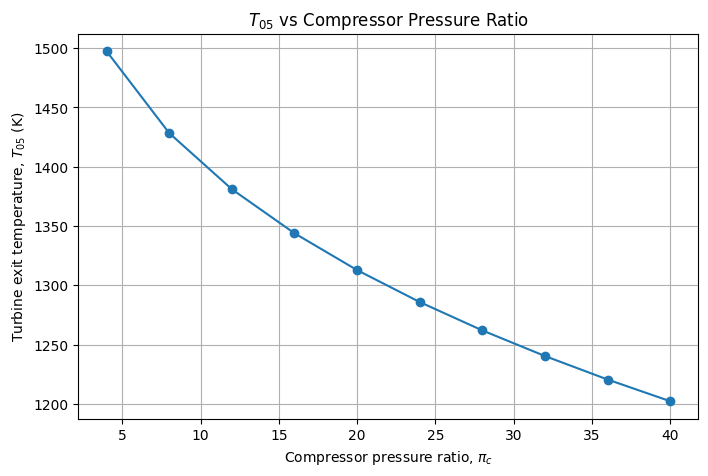

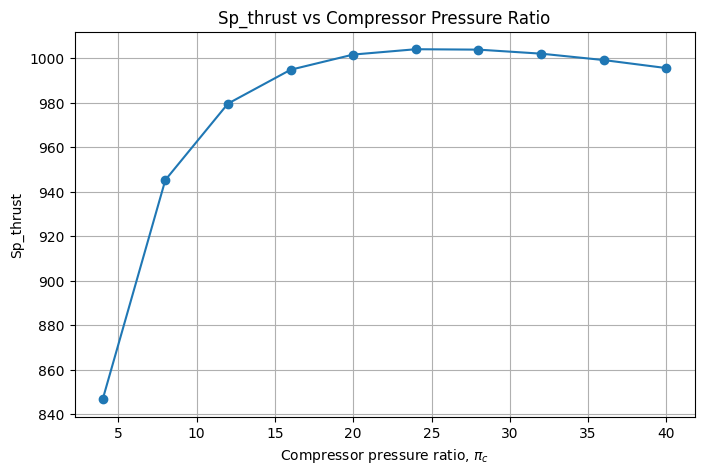

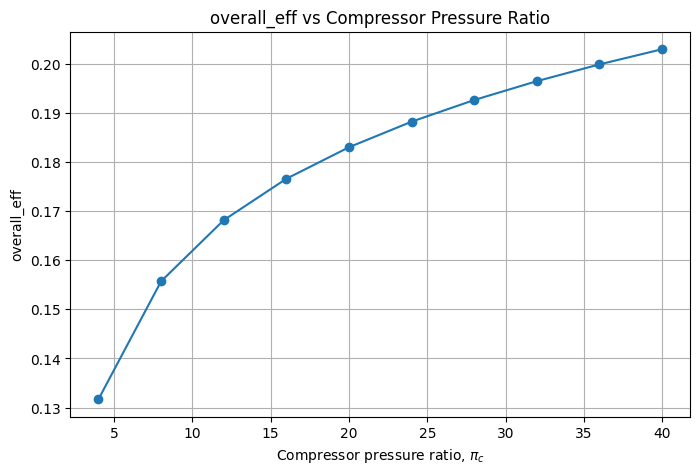

In [4]:
import math

gamma_c = 1.4 #cold section ratio of specific heats
cp_c = 1004.0 #cold section
gamma_h = 1.33 #hot section ratio of specific heats
cp_h = 1156.0 #hot section
R_air = 287.0 #J/(kg.K)
g = 9.80665 #m/s^2
h_pr = 43e6 #fuel heating value

def standard_atmosphere(altitude_m) :
  T0_sea = 288.15; #sealevel temperature 15deg_c
  p0_sea = 101325.0; #sealevel pressure
  lapse_rate = 0.0065 #K/m # temperature reduces at this rate

  if altitude_m <= 11000:
    T0 = T0_sea - lapse_rate*altitude_m
    p0 = p0_sea*(T0/T0_sea)**(g/(lapse_rate*R_air))
  else:
    T11 = T0_sea - lapse_rate*11000 #approximate isothermal after 11km
    p11 = p0_sea*(T11/T0_sea)**(g/(lapse_rate*R_air)) #pressure at 11km
    T0 = T11
    p0 = p11*math.exp(-(g*altitude_m-11000)/(R_air*T11))
  return T0, p0

def ideal_turbojet_cycle(M0, altitude_m, pi_c, T04):
  T0,p0 = standard_atmosphere(altitude_m)
  a0 = math.sqrt(gamma_c*R_air*T0) # speed of sound
  V0 = M0*a0

  #diffuser (0->2) isentropic
  tau_r = 1 + ((gamma_c-1)/2)*M0**2 #temperature ratio
  pi_d = tau_r**(gamma_c/(gamma_c-1)) #diffuser pressure ratio
  T02 = tau_r*T0
  p02 = pi_d*p0

  #compressor (2->3) isentropic
  T03 = T02*pi_c**((gamma_c-1)/gamma_c)
  p03 = pi_c*p02

  #combustor (3->4) constant pressure
  p04 = p03
  f = (cp_h*T04 - cp_c*T03)/(h_pr - cp_h*T04) #fuel-air ratio

  #turbine (4->5) isentropic
  #turbine drives the compressor - spool balance, turbine produces that much work to drive the compressor only
  #wc = wt
  #(1+f)cp_h(T04-T05) = 1.cp_c(T03-T02)
  T05 = T04 + (T02-T03)*(cp_c/cp_h)/(1+f)
  p05 = p04 * (T05/T04)**(gamma_h/(gamma_h-1))

  #nozzle (5->9) isentropic
  T09 = T05 #just put the state points of turbine outlet to nozzle inlet assuming no losses, in reality there is a duct
  p09 = p05
  T9 = T09*(p0/p09)**((gamma_h-1)/gamma_h) # gas expands all the way down to the sorrounding ambient air pressure so p0
  V9 = math.sqrt(2*cp_h*(T09-T9)) # h09 = h9 + v9^2/2

  #performance
  sp_thrust = (1+f)*V9 - V0
  tsfc = f/sp_thrust
  tsfc_g_kNs = tsfc*1e6

  prop_power = sp_thrust*V0
  kinetic_power_added = 0.5*((1+f)*V9**2 - V0**2)
  thermal_eff = kinetic_power_added/(f*h_pr)
  prop_eff = prop_power/kinetic_power_added
  overall_eff = thermal_eff*prop_eff

  return {
      "T0":T0, "p0":p0, "v0":V0,
      "T02":T02, "p02":p02,
      "T03":T03, "p03":p03,
      "T04":T04, "p04":p04,
      "T05":T05, "p05":p05,
      "T9":T9, "V9":V9,
      "f":f,
      "specific_thrust_N_per_kgps": sp_thrust,
      "tsfc_kg_per_N_s": tsfc,
      "tsfc_g_per_kN_s": tsfc_g_kNs,
      "thermal_efficiency": thermal_eff,
      "propulsive_efficiency": prop_eff,
      "overall_efficiency": overall_eff,
  }

# if __name__ == "__main__":
#     result = ideal_turbojet_cycle(
#         M0=1.0,
#         altitude_m=10000,
#         pi_c=8.0,
#         T04=1600.0,
#     )

#     print("=== Ideal Turbojet Cycle: Stage 1 ===")
#     for key, val in result.items():
#         print(f"{key:28s}: {val:.4f}")

import matplotlib.pyplot as plt

pi_c_values = [4, 8, 12, 16, 20, 24, 28, 32, 36, 40]

V9_values = []
T05_values = []
sp_thrust_values = []
prop_eff_values = []
overall_eff_values = []

for pi_c in pi_c_values:

    result = ideal_turbojet_cycle(
        M0=0.8,
        altitude_m=10000,
        pi_c=pi_c,
        T04=1600.0
    )

    V9_values.append(result["V9"])
    T05_values.append(result["T05"])
    sp_thrust_values.append(result["specific_thrust_N_per_kgps"])
    prop_eff_values.append(result["propulsive_efficiency"])
    overall_eff_values.append(result["overall_efficiency"])

# ---------------------------------------
# Plot 1: V9 vs compressor pressure ratio
# ---------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    pi_c_values,
    V9_values,
    marker='o'
)

plt.xlabel("Compressor pressure ratio, $\\pi_c$")
plt.ylabel("Nozzle exit velocity, $V_9$ (m/s)")
plt.title("$V_9$ vs Compressor Pressure Ratio")

plt.grid(True)
plt.show()


# ---------------------------------------
# Plot 2: T05 vs compressor pressure ratio
# ---------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    pi_c_values,
    T05_values,
    marker='o'
)

plt.xlabel("Compressor pressure ratio, $\\pi_c$")
plt.ylabel("Turbine exit temperature, $T_{05}$ (K)")
plt.title("$T_{05}$ vs Compressor Pressure Ratio")

plt.grid(True)
plt.show()

# ---------------------------------------
# Plot 3
# ---------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    pi_c_values,
    sp_thrust_values,
    marker='o'
)

plt.xlabel("Compressor pressure ratio, $\\pi_c$")
plt.ylabel("Sp_thrust")
plt.title("Sp_thrust vs Compressor Pressure Ratio")

plt.grid(True)
plt.show()

# ---------------------------------------
# Plot 4
# ---------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    pi_c_values,
    overall_eff_values,
    marker='o'
)

plt.xlabel("Compressor pressure ratio, $\\pi_c$")
plt.ylabel("overall_eff")
plt.title("overall_eff vs Compressor Pressure Ratio")

plt.grid(True)
plt.show()
